# Data Project Part 1: Data Exploration and Visualization
Data set chosen: Palmer Archipelago (Antarctica) penguin data  
url: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

### About the data set:
I used the simplified version of the data set:

penguins_size.csv: Simplified data from original penguin data sets. Contains variables:

species: penguin species (Chinstrap, Adélie, or Gentoo)  
culmen_length_mm: culmen length (mm)  
culmen_depth_mm: culmen depth (mm)  
flipper_length_mm: flipper length (mm)  
body_mass_g: body mass (g)  
island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)  
sex: penguin sex

# 1. load the penguins dataset

In [177]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from pathlib import Path

In [188]:
#1. load the penguins dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "penguins_size.csv"

# verify the path
# print(fname)

df = pd.read_csv(fname)

# 2. Explore the dataset


In [189]:
# 2. Explore the dataset
# 2.1 Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

#examine variable names
print(df.columns.tolist())

# view the dataset
display(df.head())
df.info()


Rows: 344
Columns: 7
['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [190]:
# identify unique categories (value_counts has dropna = True by default)
print(df["species"].value_counts().sort_index())
print(df["island"].value_counts().sort_index())
print(df["sex"].value_counts(dropna=False).sort_index(ascending=True))

species
Adelie       152
Chinstrap     68
Gentoo       124
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
sex
.           1
FEMALE    165
MALE      168
NaN        10
Name: count, dtype: int64


# 3. Explore missing values and anomalies


In [191]:
# 3. Explore missing values and anomalies
# 3.1 identify missing values
# df.isna() returns a boolean dataframe
missing_count = df.isna().sum() # works for all variables
missing_mean = df.isna().mean() * 100 # does calculations on all variables

missing_values = pd.DataFrame({
    "Count": missing_count,
    "Percent": missing_mean.map(lambda x:f"{x:0.2f}%")
})

display(missing_values)

# view observations with missing values (at least one missing value in any variable)
# axis=0 → operate down each column
# axis=1 → operate across each row
# python/pandas indexing starts at 0
# any(..) returns a pandas.Series of Boolean values
missing_rows = df[df.isna().any(axis=1)]
display(missing_rows)

,Count,Percent
species,0,0.00%
island,0,0.00%
culmen_length_mm,2,0.58%
culmen_depth_mm,2,0.58%
flipper_length_mm,2,0.58%
body_mass_g,2,0.58%
sex,10,2.91%


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


### 3.1 Reflection on missing values
The dataset contains 2 missing observations for each of the four numerical variables and 10 missing observations for the sex variable.  
The descriptive statistics calculations below removed the rows with missing values. Pandas statistical functions exclude missing values when calculating statistics, so the numerical summaries are based on 342 out of 344 observations for each numerical variable.  

The missing observations for the variable with biggest number of missing values represent 10/344 = 2.9% of the total observations which is relatively small.

They still could affect the subgroup comparisons if the missing observations are not randomly distributed.

### Numerical variables in the dataset:
 2   culmen_length_mm  
 3   culmen_depth_mm  
 4   flipper_length_mm  
 5   body_mass_g

In [192]:
# 3.2 Explore anomalies/outliers
summary = df.describe().round(2)
summary.loc["missing"] = df.isna().sum()
print(summary)

# numerical variables
numeric_cols = df.select_dtypes(include="number").columns

# calculate Q1 and Q3 for the numeric columns
Q1 = df[numeric_cols].quantile(0.25) # returns pandas series containing Q1 for each numerical variable
Q3 = df[numeric_cols].quantile(0.75)

# calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds [the 1.5 IQR fences]
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bounds:")
print(lower_bound)

print("\nUpper bounds:")
print(upper_bound)

# Identify observations that fall outside the IQR bounds
outlier_mask = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))

# Check each row for at least one potential outlier
# Returns a pandas Series of Boolean values, one for each observation
outlier_rows = df[outlier_mask.any(axis=1)]
print(outlier_rows)

print(f"Number of potential outlier observations: {len(outlier_rows)}")

         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count              342.00           342.00             342.00       342.00
mean                43.92            17.15             200.92      4201.75
std                  5.46             1.97              14.06       801.95
min                 32.10            13.10             172.00      2700.00
25%                 39.22            15.60             190.00      3550.00
50%                 44.45            17.30             197.00      4050.00
75%                 48.50            18.70             213.00      4750.00
max                 59.60            21.50             231.00      6300.00
missing              2.00             2.00               2.00         2.00
Lower bounds:
culmen_length_mm       25.3125
culmen_depth_mm        10.9500
flipper_length_mm     155.5000
body_mass_g          1750.0000
dtype: float64

Upper bounds:
culmen_length_mm       62.4125
culmen_depth_mm        23.3500
flipper_length_mm   

### 3.2 Reflection anomalies/outliers
There are 2 types of outlier analysis:  

**Overall dataset**: in the analysis above, there seems no potential outliers in the dataset overall, since all the values of the numerical variables fall in between their calculated upper and lower bounds.  

**Within Species**: introduced later in this document at the boxplot in section 5.2, potential outliers in the body mass variable appeared within the Chinstrap species with values (4800, 2700) highlighted on the boxplot out of the upper and lower bounds for that species.

other species do not seem to have outliers in the body mass variable within them.

# 4. Calculate descriptive statistics

### 4.1 Overall descriptive statistics

In [193]:
numeric_cols = df.select_dtypes(include="number").columns

# pandas stats methods skip NaN by default
# variance calculated here is sample variance with ddof = 1
descriptive_stats = df[numeric_cols].agg(func=["mean", "median", "var", "std", "min", "max"]).round(2)
print(descriptive_stats)


        culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
mean               43.92            17.15             200.92      4201.75
median             44.45            17.30             197.00      4050.00
var                29.81             3.90             197.73    643131.08
std                 5.46             1.97              14.06       801.95
min                32.10            13.10             172.00      2700.00
max                59.60            21.50             231.00      6300.00


### 4.2 Descriptivs statistics by categorical variables

In [194]:
# group by species
grouped = df.groupby("species")[numeric_cols]

# for(species, group) in grouped:
#     display(group)

grouped_mean = grouped.mean()
grouped_median = grouped.median()
grouped_variance = grouped.var()
grouped_std = grouped.std()
grouped_min = grouped.min()
grouped_max = grouped.max()

# display(grouped_mean[numeric_cols].to_numpy())
# display(grouped_mean[numeric_cols].to_numpy().flatten())

grouped_stats = pd.DataFrame({
    "species": grouped_mean.index.repeat(len(numeric_cols)).values,
    "variable": list(numeric_cols) * len(grouped_mean),

    "mean": grouped_mean[numeric_cols].to_numpy().flatten(),
    "median": grouped_median[numeric_cols].to_numpy().flatten(),
    "variance": grouped_variance[numeric_cols].to_numpy().flatten(),
    "sd": grouped_std[numeric_cols].to_numpy().flatten(),
    "min": grouped_min[numeric_cols].to_numpy().flatten(),
    "max": grouped_max[numeric_cols].to_numpy().flatten()
})

grouped_stats.iloc[:, 2:] = grouped_stats.iloc[:, 2:].round(2)

display(grouped_stats)

,species,variable,mean,median,variance,sd,min,max
0,Adelie,culmen_length_mm,38.79,38.80,7.09,2.66,32.1,46.0
1,Adelie,culmen_depth_mm,18.35,18.40,1.48,1.22,15.5,21.5
2,Adelie,flipper_length_mm,189.95,190.00,42.76,6.54,172.0,210.0
3,Adelie,body_mass_g,3700.66,3700.00,210282.89,458.57,2850.0,4775.0
4,Chinstrap,culmen_length_mm,48.83,49.55,11.15,3.34,40.9,58.0
5,Chinstrap,culmen_depth_mm,18.42,18.45,1.29,1.14,16.4,20.8
6,Chinstrap,flipper_length_mm,195.82,196.00,50.86,7.13,178.0,212.0
7,Chinstrap,body_mass_g,3733.09,3700.00,147713.45,384.34,2700.0,4800.0
8,Gentoo,culmen_length_mm,47.50,47.30,9.50,3.08,40.9,59.6
9,Gentoo,culmen_depth_mm,14.98,15.00,0.96,0.98,13.1,17.3


# 5. Visualizations

### 5.1 Histogram of body mass

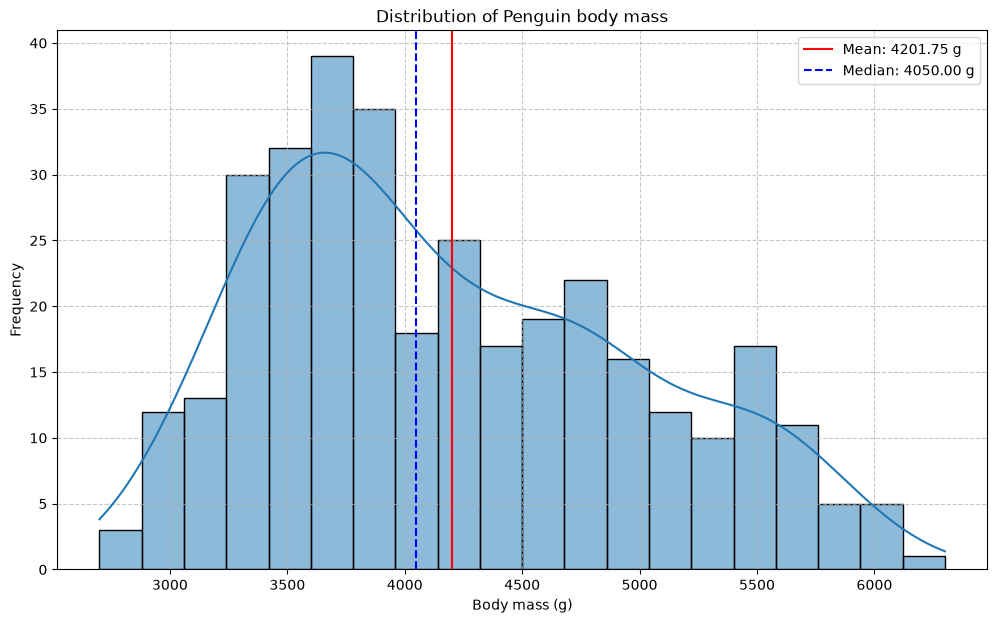

In [195]:
# plt.hist(x=df["body_mass_g"].dropna(), bins=20)
plt.figure(figsize=(12, 7))
sns.histplot(data=df["body_mass_g"].dropna(), bins=20, kde=True)

plt.xlabel("Body mass (g)")
plt.ylabel("Frequency")
plt.title("Distribution of Penguin body mass")
plt.grid(axis="both", linestyle="--", alpha=0.7)

# display mean and median on the histogram
mean_body_mass = df["body_mass_g"].mean()
median_body_mass = df["body_mass_g"].median()

plt.axvline(mean_body_mass, linestyle="-", color="red", label=f"Mean: {mean_body_mass:.2f} g")
plt.axvline(median_body_mass, linestyle="--", color="blue", label=f"Median: {median_body_mass:.2f} g")

plt.legend()


### 5.2 Boxplot of body mass by species

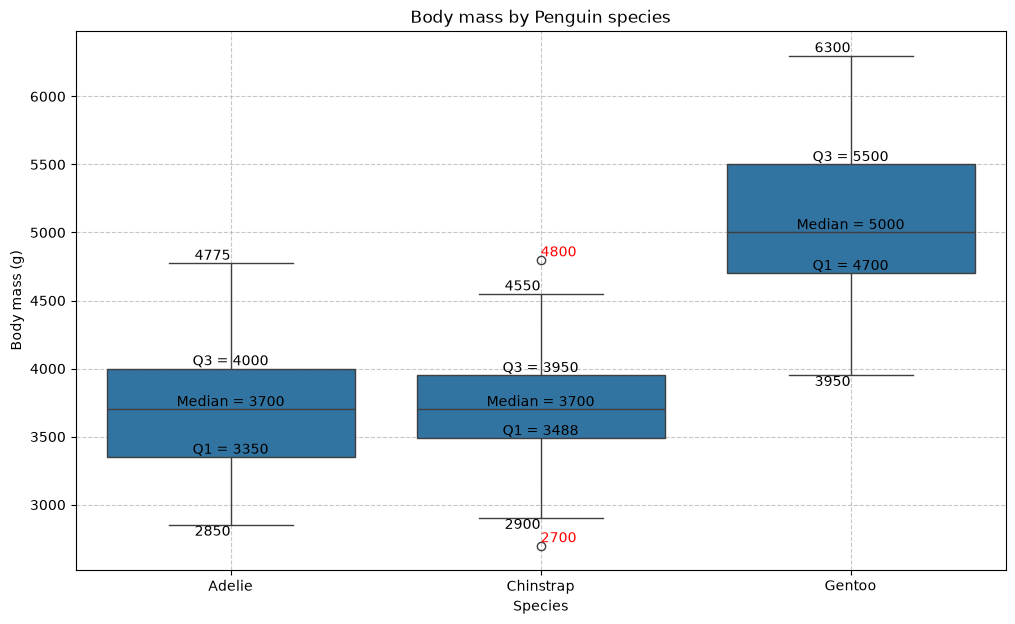

In [196]:
plt.figure(figsize=(12, 7))

ax = sns.boxplot(data=df, x="species", y="body_mass_g")

# display stats on the box plot
species_list = df["species"].dropna().unique()
for i, species in enumerate(species_list):
    values = df.loc[df["species"] == species, "body_mass_g"].dropna()

    Q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    Q3 = values.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Actual whisker values
    lower_whisker = values[values >= lower_bound].min()
    upper_whisker = values[values <= upper_bound].max()

    # Display values
    ax.text(i, Q1, f"Q1 = {Q1:.0f}", ha="center", va="bottom")
    ax.text(i, median, f"Median = {median:.0f}", ha="center", va="bottom")
    ax.text(i, Q3, f"Q3 = {Q3:.0f}", ha="center", va="bottom")
    ax.text(i, lower_whisker, f"{lower_whisker:.0f}", ha="right", va="top")
    ax.text(i, upper_whisker, f"{upper_whisker:.0f}", ha="right", va="bottom")

    # there seems to be potential outliers in the Chinstrap species
    outliers = values[(values > upper_bound) | (values < lower_bound)]

    for outlier in outliers:
        ax.text(i, outlier, f"{outlier:.0f}", ha="left", va="bottom", color="red")


# grid and labels
plt.xlabel("Species")
plt.ylabel("Body mass (g)")
plt.title("Body mass by Penguin species")
plt.grid(axis="both", linestyle="--", alpha=0.7)




### 5.3 Scatterplot of flipper length vs body mass

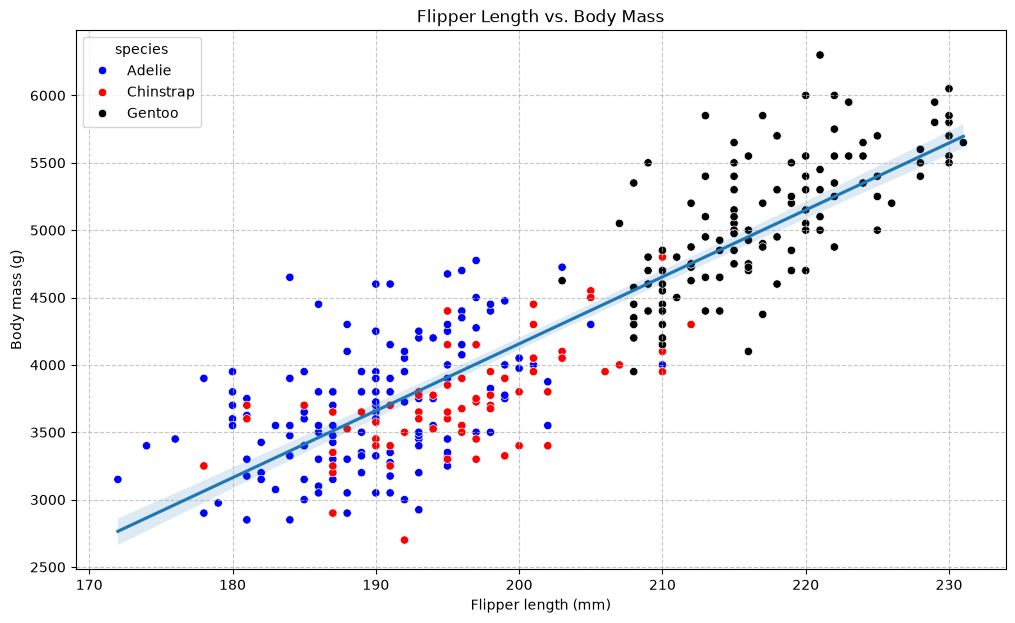

In [197]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette={
        "Adelie": "blue",
        "Chinstrap": "red",
        "Gentoo": "black"
    }
)

sns.regplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    scatter=False
)

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Flipper Length vs. Body Mass")
plt.grid(axis="both", linestyle="--", alpha=0.7)

# Reflection:

## Descriptive Statistics:
Descriptive statistics were calculated for the four numerical variables. These included the mean, median, variance, standard deviation, minimum, and maximum.

### 4.1 Overall descriptive statistics:
overall mean body-mass is 4201.75 grams, and the median is 4050 grams, i.e mean > median, which is consistent with some higher body-mass observations pulling the mean upward. The histogram also appears to have a somewhat longer upper tail.  

The average culmen length was approximately 43.92 mm, while the average culmen depth was 17.15 mm. The average flipper length was approximately 200.92 mm.

The body-mass measurements ranged from 2700 grams to 6300 grams, showing substantial variation in the size of the penguins represented in the dataset.

### 4.2 Descriptive statistics by category (species was chosen):
The **Adelie** species have an average body-mass of 3700 grams which is pretty close to that of the **Chinstrap**'s mean body-mass of 3733 grams, while the **Gentoo** has a higher mean body-mass at 5076 grams

The flipper length looks proportional with the body-mass, with the **Adelie** having a mean flipper length of approximately 190 mm, while it is around 196 mm for the **Chinstrap**, and the longest for the **Gentoo** at 217 mm

The species also differ in culmen measurements. **Chinstrap** penguins have the highest mean culmen length at approximately 48.83 mm, followed by **Gentoo** at 47.50 mm and **Adelie** at 38.79 mm. In contrast, **Gentoo** penguins have a substantially lower average culmen depth, approximately 14.98 mm, compared with 18.35 mm for **Adelie** and 18.42 mm for **Chinstrap**.

### 5 visualizations

#### 5.1 histogram of Body Mass
The body mass distribution has considerable variation of values with most of values ranging between "approximately" 3250 and 4250 grams, in the lower to middle portion of the overall range.  

The values are spread in between 2700 and 6300 grams.  
the graph looks to have longer upper tail with some higher values of body mass pulling the mean value to the right of the median, with the mean at 4201.75 and the median is at 4050 grams.  

#### 5.2 Boxplot by species
The body-mass differs across the 3 different species:
    **Adelie** have body mass values ranging from 2850 to 4775 grams  
    **Chinstrap** have values ranging from 2700 to 4800 grams (although 2700 and 4800 are identified as potential outliers using the 1.5 × IQR rule.)  
    **Gentoo** with values between 3950, and 6300 grams

The Boxplot also suggests that the Chinstrap may have potential outliers at the values highlighted, 2700, and 4800 grams falling out of the calculated upper and lower bounds ranging 1.5 IQR from both Q1 and Q3.  
while there were no potential outliers in the overall analysis of the dataset.

#### 5.3 Scatterplot of Flipper Length and Body Mass

The scatterplot compares flipper length with body mass. The plot shows a positive association between the two variables: penguins with longer flippers generally tend to have greater body mass.

The observations are also separated by species in the visualization. The species occupy somewhat different regions of the plot, with Gentoo penguins generally appearing toward the higher end of both flipper length and body mass, while Adelie penguins generally appear toward the lower end

The regression line provides a visual summary of the overall positive relationship between the two numerical variables. However, this relationship represents an association and does not establish that longer flippers cause greater body mass.